In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import torch
from torch.utils.data import Dataset, DataLoader

# Set plotting style
# plt.style.use('seaborn')
sns.set_palette('husl')

In [28]:
import os
import json
import numpy as np
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader, random_split
import torch

from base import BaseDataLoader, DatasetSubset

import os
import json
import numpy as np
from collections import defaultdict
from torch.utils.data import Dataset
import torch

class ShakespeareDataset(Dataset):
    def __init__(self, data_dir, train=True, iid=False, num_clients=None):
        super().__init__()
        train_dir = os.path.join(data_dir, 'train')
        test_dir = os.path.join(data_dir, 'test')
        
        # Read data first
        self.train_clients, _, self.train_data, self.test_data = self._read_data(train_dir, test_dir)
        self.train = train
        self.iid = iid
        self.num_clients = num_clients if num_clients else len(self.train_clients)
        
        # Create vocabulary before preparing data
        self._create_vocabulary()
        
        # Prepare data after vocabulary is created
        if self.train:
            self.data, self.labels, self.client_indices = self._prepare_training_data()
        else:
            self.data, self.labels = self._prepare_test_data()

    def _create_vocabulary(self):
        """Create vocabulary from all available data (train and test)"""
        all_chars = set()
        
        # Collect characters from training data
        for client in self.train_clients:
            # Add characters from input sequences
            if self.train_data[client] is not None:
                all_chars.update(''.join(self.train_data[client]['x']))
                # Add characters from labels
                all_chars.update(''.join(str(c) for c in self.train_data[client]['y']))
            
            # Add characters from test data
            if self.test_data[client] is not None:
                all_chars.update(''.join(self.test_data[client]['x']))
                all_chars.update(''.join(str(c) for c in self.test_data[client]['y']))
        
        # Add special tokens
        special_tokens = {'<PAD>', '<UNK>'}
        all_chars.update(special_tokens)
        
        # Create character to index mapping
        self.char_to_idx = {char: idx for idx, char in enumerate(sorted(special_tokens) + sorted(all_chars - special_tokens))}
        self.idx_to_char = {idx: char for char, idx in self.char_to_idx.items()}
        self.vocab_size = len(self.char_to_idx)
        self.pad_idx = self.char_to_idx['<PAD>']
        self.unk_idx = self.char_to_idx['<UNK>']

    def _read_data(self, train_dir, test_dir):
        """Read data from json files"""
        def read_dir(data_dir):
            clients = []
            groups = []
            data = defaultdict(lambda: None)
            
            files = [f for f in os.listdir(data_dir) if f.endswith('.json')]
            for f in files:
                file_path = os.path.join(data_dir, f)
                with open(file_path, 'r') as inf:
                    cdata = json.load(inf)
                clients.extend(cdata['users'])
                if 'hierarchies' in cdata:
                    groups.extend(cdata['hierarchies'])
                data.update(cdata['user_data'])
            
            return sorted(list(set(clients))), groups, data

        train_clients, train_groups, train_data = read_dir(train_dir)
        test_clients, test_groups, test_data = read_dir(test_dir)
        
        return train_clients, train_groups, train_data, test_data

    def _prepare_training_data(self):
        """Now only handles IID split"""
        all_data = []
        all_labels = []
        
        # Collect all data from all clients
        for client in self.train_clients:
            if self.train_data[client] is not None:
                all_data.extend(self.train_data[client]['x'])
                all_labels.extend(self.train_data[client]['y'])
                
        # Shuffle data
        indices = list(range(len(all_data)))
        np.random.shuffle(indices)
        
        # Split data evenly among clients
        samples_per_client = len(indices) // self.num_clients
        remaining_samples = len(indices) % self.num_clients
        client_indices = {}
        
        current_idx = 0
        for i in range(self.num_clients):
            # Distribute remaining samples evenly
            extra_sample = 1 if i < remaining_samples else 0
            client_size = samples_per_client + extra_sample
            
            end_idx = current_idx + client_size
            client_indices[i] = set(range(current_idx, end_idx))
            current_idx = end_idx
                
        return [all_data[i] for i in indices], [all_labels[i] for i in indices], client_indices
    
    def _prepare_test_data(self):
        """Prepare test data"""
        all_data = []
        all_labels = []
        for client in self.train_clients:
            if self.test_data[client] is not None:
                all_data.extend(self.test_data[client]['x'])
                all_labels.extend(self.test_data[client]['y'])
        return all_data, all_labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        """Get a single item from the dataset"""
        sequence = self.data[index]
        target = self.labels[index]
        
        # Convert sequence to indices
        if isinstance(sequence, str):
            sequence_indices = torch.tensor([
                self.char_to_idx[c] for c in sequence
            ], dtype=torch.long)
        else:
            sequence_indices = torch.tensor(sequence, dtype=torch.long)
        
        # Convert target to single index
        if isinstance(target, str):
            target_idx = self.char_to_idx[target]
            target_tensor = torch.tensor(target_idx, dtype=torch.long)
        else:
            target_tensor = torch.tensor(target, dtype=torch.long)
        
        return sequence_indices, target_tensor

    def get_vocab_size(self):
        """Return the vocabulary size"""
        return self.vocab_size

    def decode_sequence(self, indices):
        """Convert a sequence of indices back to characters"""
        return ''.join(self.idx_to_char.get(idx.item(), '<UNK>') for idx in indices)

class ShakespeareDataLoader(BaseDataLoader):
    def __init__(self, data_dir: str, n_clients: int, batch_size: int, iid: bool = True):
        super().__init__(data_dir, n_clients, batch_size, iid)

    def load_data(self):
        # Load datasets
        train_dataset = ShakespeareDataset(
            data_dir=self.data_dir,
            train=True,
            iid=self.iid,
            num_clients=self.n_clients
        )
        test_dataset = ShakespeareDataset(
            data_dir=self.data_dir,
            train=False
        )

        # Split test into validation and test
        test_size = len(test_dataset)
        val_size = int(0.2 * test_size)
        test_size = test_size - val_size
        val_dataset, test_dataset = random_split(test_dataset, [val_size, test_size])

        # Create dataloaders using client indices from dataset
        train_loaders = [
            DataLoader(
                DatasetSubset(train_dataset, train_dataset.client_indices[i]),
                batch_size=self.batch_size,
                shuffle=True
            ) for i in range(self.n_clients)
        ]
        val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False)

        return train_loaders, val_loader, test_loader, None  # None for text data

=== Shakespeare Dataset Analysis ===

1. Basic Statistics:
Total samples: 734057
Vocabulary size: 79
Number of clients: 10
Average samples per client: 73405.70
Min samples per client: 73405
Max samples per client: 73406

2. Vocabulary Analysis:

Top 10 most common characters:
' ': 18.73%
'e': 8.90%
't': 6.38%
'o': 6.14%
'a': 5.39%
'h': 4.91%
's': 4.73%
'n': 4.71%
'r': 4.49%
'i': 4.37%


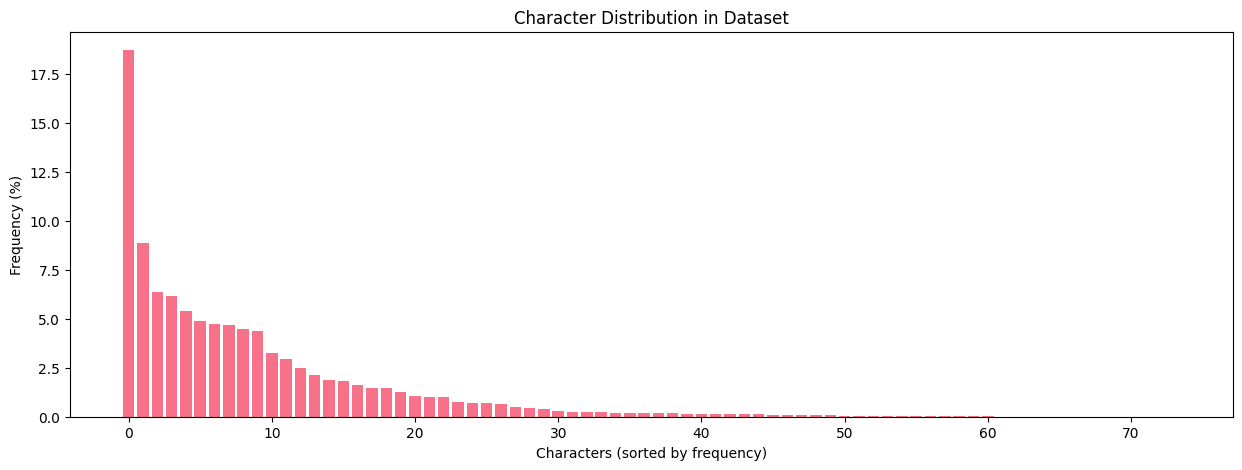


3. Sequence Length Analysis:
Average sequence length: 80.00
Min sequence length: 80
Max sequence length: 80


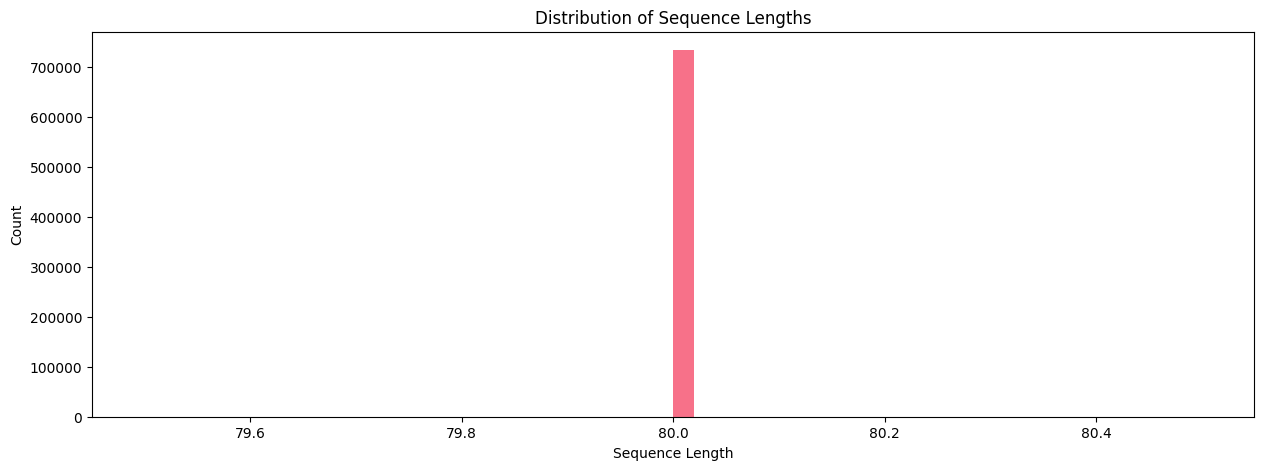


4. Client Data Distribution:


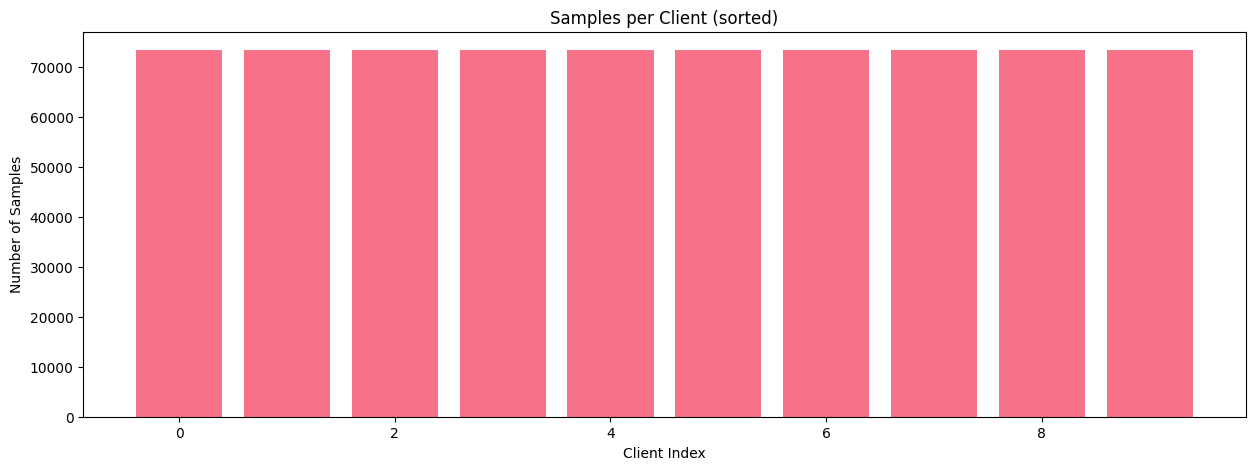


5. Sample Sequences:

Sample 1:
Input sequence: hom I might command it? Come thou near. Didst thou behold Octavia? Where? Is she
Target character: ' '
Sequence length: 80

Sample 2:
Input sequence: t to be question'd That they had gather'd a wise council to them Of every realm,
Target character: ' '
Sequence length: 80

Sample 3:
Input sequence: well. France, thou shalt rue this treason with thy tears, If Talbot but survive 
Target character: 't'
Sequence length: 80

Sample 4:
Input sequence: n; as he pass'd along, How earnestly he cast his eyes upon me! Pray heaven he so
Target character: 'u'
Sequence length: 80

Sample 5:
Input sequence: t of deeds too cold breath gives. A bell rings. I go, and it is done; the bell i
Target character: 'n'
Sequence length: 80


In [18]:
def analyze_shakespeare_dataset(dataset):
    print("=== Shakespeare Dataset Analysis ===\n")
    
    # 1. Basic Statistics
    print("1. Basic Statistics:")
    print(f"Total samples: {len(dataset.data)}")
    print(f"Vocabulary size: {dataset.vocab_size}")
    print(f"Number of clients: {dataset.num_clients}")
    
    # Calculate samples per client
    samples_per_client = [len(indices) for indices in dataset.client_indices.values()]
    print(f"Average samples per client: {np.mean(samples_per_client):.2f}")
    print(f"Min samples per client: {np.min(samples_per_client)}")
    print(f"Max samples per client: {np.max(samples_per_client)}")
    
    # 2. Vocabulary Analysis
    print("\n2. Vocabulary Analysis:")
    char_freq = defaultdict(int)
    for sequence in dataset.data:
        for char in sequence:
            char_freq[char] += 1
    
    total_chars = sum(char_freq.values())
    # Convert to percentage and sort
    char_freq_percent = {k: (v/total_chars)*100 for k, v in char_freq.items()}
    sorted_chars = sorted(char_freq_percent.items(), key=lambda x: x[1], reverse=True)
    
    print("\nTop 10 most common characters:")
    for char, freq in sorted_chars[:10]:
        print(f"'{char}': {freq:.2f}%")
    
    # Plot character distribution
    plt.figure(figsize=(15, 5))
    plt.bar(range(len(sorted_chars)), [x[1] for x in sorted_chars])
    plt.title('Character Distribution in Dataset')
    plt.xlabel('Characters (sorted by frequency)')
    plt.ylabel('Frequency (%)')
    plt.show()
    
    # 3. Sequence Length Analysis
    print("\n3. Sequence Length Analysis:")
    lengths = [len(seq) for seq in dataset.data]
    print(f"Average sequence length: {np.mean(lengths):.2f}")
    print(f"Min sequence length: {np.min(lengths)}")
    print(f"Max sequence length: {np.max(lengths)}")
    
    plt.figure(figsize=(15, 5))
    plt.hist(lengths, bins=50)
    plt.title('Distribution of Sequence Lengths')
    plt.xlabel('Sequence Length')
    plt.ylabel('Count')
    plt.show()
    
    # 4. Client Data Distribution
    print("\n4. Client Data Distribution:")
    plt.figure(figsize=(15, 5))
    plt.bar(range(dataset.num_clients), sorted(samples_per_client, reverse=True))
    plt.title('Samples per Client (sorted)')
    plt.xlabel('Client Index')
    plt.ylabel('Number of Samples')
    plt.show()
    
    # 5. Sample Sequences
    print("\n5. Sample Sequences:")
    for i in range(5):
        idx = np.random.randint(len(dataset))
        sequence, target = dataset[idx]
        sequence_text = ''.join([dataset.idx_to_char[idx.item()] for idx in sequence])
        target_text = dataset.idx_to_char[target.item()]
        print(f"\nSample {i+1}:")
        print(f"Input sequence: {sequence_text}")
        print(f"Target character: '{target_text}'")
        print(f"Sequence length: {len(sequence_text)}")
    
    return {
        'total_samples': len(dataset.data),
        'vocab_size': dataset.vocab_size,
        'num_clients': dataset.num_clients,
        'avg_samples_per_client': np.mean(samples_per_client),
        'char_distribution': char_freq_percent,
        'avg_sequence_length': np.mean(lengths)
    }

# Initialize and analyze dataset
data_dir = '../data/Shakespeare/'
dataset = ShakespeareDataset(data_dir, train=True, num_clients=10)  # Adjust num_clients as needed
stats = analyze_shakespeare_dataset(dataset)

In [30]:
# Test getitem
def test_getitem(dataset):
    idx = 0
    sequence, target = dataset[idx]
    
    print("Input sequence:")
    print("Original:", dataset.data[idx])
    print("As tensor:", sequence)
    print("Shape:", sequence.shape)
    print("\nTarget:")
    print("Original:", dataset.labels[idx])
    print("As tensor:", target)
    print("Shape:", target.shape)
    
    # Decode back
    decoded_sequence = ''.join([dataset.idx_to_char[idx.item()] for idx in sequence])
    decoded_target = dataset.idx_to_char[target.item()]
    print("\nDecoded:")
    print("Sequence:", decoded_sequence)
    print("Target:", decoded_target)

test_getitem(dataset)

Input sequence:
Original: nts of packthread, and old cakes of roses Were thinly scattered, to make up a sh
As tensor: tensor([66, 72, 71,  2, 67, 58,  2, 68, 53, 55, 63, 72, 60, 70, 57, 53, 56,  9,
         2, 53, 66, 56,  2, 67, 64, 56,  2, 55, 53, 63, 57, 71,  2, 67, 58,  2,
        70, 67, 71, 57, 71,  2, 47, 57, 70, 57,  2, 72, 60, 61, 66, 64, 77,  2,
        71, 55, 53, 72, 72, 57, 70, 57, 56,  9,  2, 72, 67,  2, 65, 53, 63, 57,
         2, 73, 68,  2, 53,  2, 71, 60])
Shape: torch.Size([80])

Target:
Original: o
As tensor: tensor(67)
Shape: torch.Size([])

Decoded:
Sequence: nts of packthread, and old cakes of roses Were thinly scattered, to make up a sh
Target: o
